# Phase 02 — Extended Error Analysis (FP/FN by Genre, Budget, Year)

Per the KT2 guide (Faza B): extend the error-analysis section by **grouping errors by genre, budget, and release year**. This reveals systematic weaknesses (e.g. certain genres or budget bands) and supports 1–2 paragraphs in the final report.

We analyse **false positives** (predicted positive, actually negative) and **false negatives** (predicted negative, actually positive) for **commercial success** and optionally **award winner**. Run from `phase_02/`.

## Setup — load notebook 04 results

Run **`04_model_improvements.ipynb`** first (final cell saves `data/processed/phase2_results.pkl`).  
We use **best tuned** model per target on **`7_+runtime`** (highest test F1@opt from `tuning_results`).  
Predictions use the **validation-optimal threshold** (`best_threshold`) when probabilities are available.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

plt.style.use('default')
sns.set_palette('husl')
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)
DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'

pkl_path = PROCESSED_DIR / 'phase2_results.pkl'
if not pkl_path.exists():
    raise FileNotFoundError(f'Run 04_model_improvements first. Missing: {pkl_path}')

with open(pkl_path, 'rb') as f:
    bundle = pickle.load(f)

modeling_df = bundle['modeling_df']
unique_genres = bundle['unique_genres']
all_splits = bundle['all_splits']
tuning_results = bundle['tuning_results']

SET_NAME = '7_+runtime'


def pick_best_tuned_key(tuned_by_model):
    best_k, best_f1 = None, -1.0
    for k, r in tuned_by_model.items():
        if not isinstance(r, dict) or 'test_f1' not in r:
            continue
        f1 = r.get('test_f1_opt') or r.get('test_f1') or 0
        if f1 > best_f1:
            best_f1, best_k = f1, k
    return best_k, best_f1


def preds_from_tuned(r):
    y_true = r['y_test']
    proba = r.get('y_test_proba')
    thr = r.get('best_threshold', 0.5)
    if proba is not None:
        y_hat = (proba >= thr).astype(int)
    else:
        y_hat = r['y_test_pred']
    return y_true, y_hat


split_comm = all_splits[SET_NAME]['is_commercial']
split_award = all_splits[SET_NAME]['is_award_winner']
t_comm = tuning_results[SET_NAME]['is_commercial']
t_award = tuning_results[SET_NAME]['is_award_winner']

k_comm, f1_comm = pick_best_tuned_key(t_comm)
k_award, f1_award = pick_best_tuned_key(t_award)
print(f'Commercial — best tuned: {k_comm} (F1@opt ~ {f1_comm:.3f})')
print(f'Award — best tuned: {k_award} (F1@opt ~ {f1_award:.3f})')

y_test_comm, y_pred_comm = preds_from_tuned(t_comm[k_comm])
y_test_award, y_pred_award = preds_from_tuned(t_award[k_award])

Commercial — best tuned: RF (F1@opt ~ 0.664)
Award — best tuned: XGB (F1@opt ~ 0.490)


## Build error DataFrames (commercial & award)

Merge test indices with `modeling_df` to get genre, budget, year for each test sample. Add FP/FN flags.

In [2]:
test_idx_comm = split_comm['X_test'].index
err_comm = modeling_df.loc[test_idx_comm].copy()
err_comm['true'] = y_test_comm.values
err_comm['pred'] = y_pred_comm
err_comm['fp'] = (y_pred_comm == 1) & (y_test_comm.values == 0)
err_comm['fn'] = (y_pred_comm == 0) & (y_test_comm.values == 1)

test_idx_award = split_award['X_test'].index
err_award = modeling_df.loc[test_idx_award].copy()
err_award['true'] = y_test_award.values
err_award['pred'] = y_pred_award
err_award['fp'] = (y_pred_award == 1) & (y_test_award.values == 0)
err_award['fn'] = (y_pred_award == 0) & (y_test_award.values == 1)

print('Commercial: FP =', err_comm['fp'].sum(), ', FN =', err_comm['fn'].sum(), ', test n =', len(err_comm))
print('Award:      FP =', err_award['fp'].sum(), ', FN =', err_award['fn'].sum(), ', test n =', len(err_award))

Commercial: FP = 377 , FN = 25 , test n = 869
Award:      FP = 141 , FN = 46 , test n = 869


## Budget bins

Define budget bands (e.g. low / medium / high) and count FP/FN per band.

In [3]:
def add_budget_band(df):
    b = df['budget']
    df = df.copy()
    df['budget_band'] = pd.cut(b, bins=[0, 1e6, 1e7, 5e7, np.inf],
                                labels=['<1M', '1M–10M', '10M–50M', '>50M'])
    return df

err_comm = add_budget_band(err_comm)
err_award = add_budget_band(err_award)

def fp_fn_by(df, group_col):
    total = df.groupby(group_col).size()
    fp = df[df['fp']].groupby(group_col).size().reindex(total.index).fillna(0).astype(int)
    fn = df[df['fn']].groupby(group_col).size().reindex(total.index).fillna(0).astype(int)
    out = pd.DataFrame({'total': total, 'FP': fp, 'FN': fn})
    out['FP_rate'] = (out['FP'] / out['total']).round(3)
    out['FN_rate'] = (out['FN'] / out['total']).round(3)
    return out

print('--- Commercial: FP/FN by budget_band ---')
display(fp_fn_by(err_comm, 'budget_band'))
print('--- Award: FP/FN by budget_band ---')
display(fp_fn_by(err_award, 'budget_band'))

--- Commercial: FP/FN by budget_band ---


,total,FP,FN,FP_rate,FN_rate
budget_band,,,,,
<1M,53,22,0,0.415,0.000
1M–10M,266,108,5,0.406,0.019
10M–50M,378,174,18,0.460,0.048
>50M,172,73,2,0.424,0.012


--- Award: FP/FN by budget_band ---


,total,FP,FN,FP_rate,FN_rate
budget_band,,,,,
<1M,54,4,3,0.074,0.056
1M–10M,262,53,14,0.202,0.053
10M–50M,366,65,19,0.178,0.052
>50M,187,19,10,0.102,0.053


## Release year

Group errors by release year (or year bins if too many levels).

In [4]:
err_comm['year_band'] = pd.cut(err_comm['release_year'], bins=[0, 1995, 2005, 2015, 2030],
                                labels=['before 1995', '1995–2005', '2005–2015', '2015+'])
err_award['year_band'] = pd.cut(err_award['release_year'], bins=[0, 1995, 2005, 2015, 2030],
                                labels=['before 1995', '1995–2005', '2005–2015', '2015+'])

print('--- Commercial: FP/FN by year_band ---')
display(fp_fn_by(err_comm, 'year_band'))
print('--- Award: FP/FN by year_band ---')
display(fp_fn_by(err_award, 'year_band'))

--- Commercial: FP/FN by year_band ---


,total,FP,FN,FP_rate,FN_rate
year_band,,,,,
before 1995,259,100,8,0.386,0.031
1995–2005,202,102,4,0.505,0.020
2005–2015,248,92,8,0.371,0.032
2015+,160,83,5,0.519,0.031


--- Award: FP/FN by year_band ---


,total,FP,FN,FP_rate,FN_rate
year_band,,,,,
before 1995,254,42,21,0.165,0.083
1995–2005,195,37,9,0.190,0.046
2005–2015,251,39,10,0.155,0.040
2015+,169,23,6,0.136,0.036


## Genre

For each movie we may have multiple genres. We consider **primary genre** as the first genre column that is 1 (or aggregate over all genre columns). Here we aggregate: count FP/FN per genre by summing over rows where that genre column is 1.

In [5]:
genre_cols = [f'genre_{g.lower()}' for g in unique_genres]
genre_cols = [c for c in genre_cols if c in err_comm.columns]

def fp_fn_by_genre(err_df):
    rows = []
    for g in genre_cols:
        subset = err_df[err_df[g] == 1]
        n = len(subset)
        if n == 0:
            continue
        rows.append({
            'genre': g.replace('genre_', ''),
            'total': n,
            'FP': subset['fp'].sum(),
            'FN': subset['fn'].sum(),
            'FP_rate': subset['fp'].mean().round(3),
            'FN_rate': subset['fn'].mean().round(3),
        })
    return pd.DataFrame(rows).sort_values('total', ascending=False)

print('--- Commercial: FP/FN by genre ---')
display(fp_fn_by_genre(err_comm))
print('--- Award: FP/FN by genre ---')
display(fp_fn_by_genre(err_award))

--- Commercial: FP/FN by genre ---


,genre,total,FP,FN,FP_rate,FN_rate
6,drama,421,188,22,0.447,0.052
3,comedy,304,129,5,0.424,0.016
16,thriller,229,100,5,0.437,0.022
0,action,207,91,4,0.440,0.019
1,adventure,168,69,4,0.411,0.024
13,romance,164,72,7,0.439,0.043
4,crime,156,68,7,0.436,0.045
10,horror,97,40,0,0.412,0.000
14,science fiction,94,46,0,0.489,0.000
7,family,92,38,1,0.413,0.011


--- Award: FP/FN by genre ---


,genre,total,FP,FN,FP_rate,FN_rate
6,drama,375,121,18,0.323,0.048
3,comedy,321,48,22,0.150,0.069
15,thriller,252,29,12,0.115,0.048
0,action,241,2,14,0.008,0.058
1,adventure,195,5,10,0.026,0.051
4,crime,170,32,8,0.188,0.047
13,romance,158,51,10,0.323,0.063
14,science fiction,113,6,7,0.053,0.062
10,horror,103,2,4,0.019,0.039
8,fantasy,101,11,4,0.109,0.040


## Visualisation: FP/FN rates by budget and year

Bar plots for report.

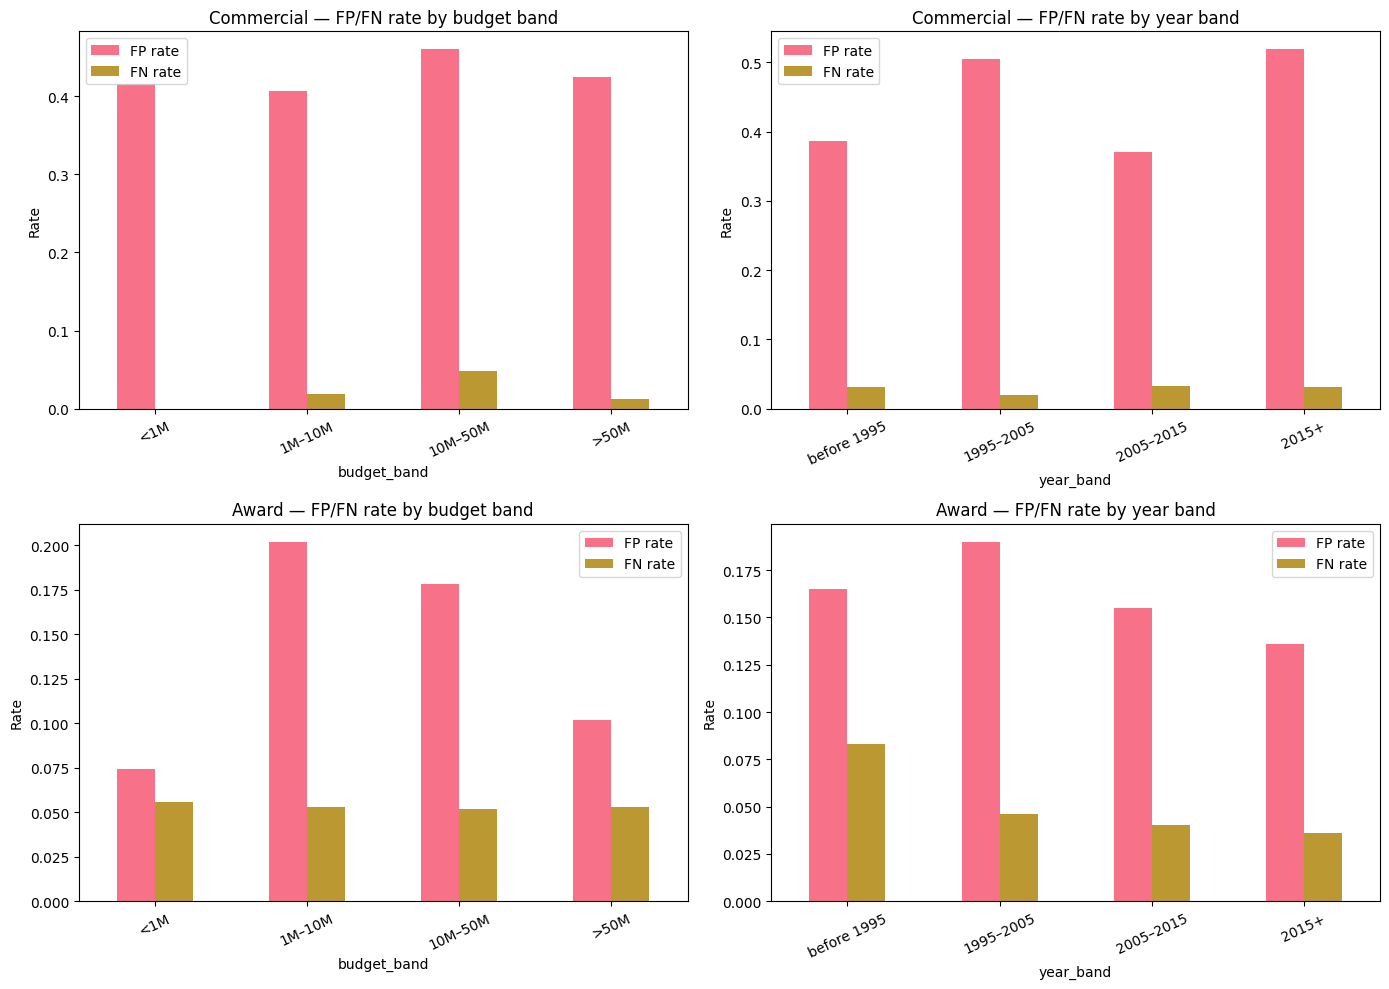

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

by_budget_c = fp_fn_by(err_comm, 'budget_band')
by_budget_c[['FP_rate', 'FN_rate']].plot(kind='bar', ax=axes[0, 0], color=['C0', 'C1'])
axes[0, 0].set_title('Commercial — FP/FN rate by budget band')
axes[0, 0].set_xticklabels(by_budget_c.index, rotation=25)
axes[0, 0].legend(['FP rate', 'FN rate'])
axes[0, 0].set_ylabel('Rate')

by_year_c = fp_fn_by(err_comm, 'year_band')
by_year_c[['FP_rate', 'FN_rate']].plot(kind='bar', ax=axes[0, 1], color=['C0', 'C1'])
axes[0, 1].set_title('Commercial — FP/FN rate by year band')
axes[0, 1].set_xticklabels(by_year_c.index, rotation=25)
axes[0, 1].legend(['FP rate', 'FN rate'])
axes[0, 1].set_ylabel('Rate')

by_budget_a = fp_fn_by(err_award, 'budget_band')
by_budget_a[['FP_rate', 'FN_rate']].plot(kind='bar', ax=axes[1, 0], color=['C0', 'C1'])
axes[1, 0].set_title('Award — FP/FN rate by budget band')
axes[1, 0].set_xticklabels(by_budget_a.index, rotation=25)
axes[1, 0].legend(['FP rate', 'FN rate'])
axes[1, 0].set_ylabel('Rate')

by_year_a = fp_fn_by(err_award, 'year_band')
by_year_a[['FP_rate', 'FN_rate']].plot(kind='bar', ax=axes[1, 1], color=['C0', 'C1'])
axes[1, 1].set_title('Award — FP/FN rate by year band')
axes[1, 1].set_xticklabels(by_year_a.index, rotation=25)
axes[1, 1].legend(['FP rate', 'FN rate'])
axes[1, 1].set_ylabel('Rate')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'error_analysis_budget_year.png', dpi=150, bbox_inches='tight')
plt.show()

## Report summary (1–2 paragraphs)

Use the tables and plots above to write 1–2 short paragraphs for the final report:

- **Commercial:** Where does the model err most? (e.g. low-budget films often predicted as commercial — FP; or high-budget dramas predicted as not commercial — FN.) Certain genres (e.g. Drama, Comedy) may have higher FP or FN rates.
- **Award:** Similarly, which budget bands or genres drive FP/FN? (e.g. mainstream blockbusters predicted as award winners — FP; or arthouse films missed — FN.)

These findings support the "Error analysis" subsection in the report and suggest directions for feature engineering or data collection (e.g. more lexical or sentiment features for specific genres).